# Data Extraction

In [1]:
import obspy, tqdm, utils, os, random, math
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

np.random.seed(67)

## Creating waveform dataset

### 1. Extract pick information from quakeML files into `df_pick`

Takes 1.5 min to run (Cubbli linux).

In [2]:
data_dir = Path(utils.DATA_DIR)

paths = {
    "earthquakes": data_dir / "earthquakes2025.qkml",
    "explosions": data_dir / "explosions2025.qkml",
}

catalogs = {}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    catalogs[name] = obspy.read_events(str(path))
    print(f"{name}: {len(catalogs[name])} events loaded from {path.name}")

# Dataframe of all earthquake, explosion and probable_explosion picks               
df_picks = utils.extract_picks(catalogs)
df_picks.to_csv(utils.FILENAME_PICKS, index=False) # Export to csv for possible debugging

print(f"\nTotal number of picks: {len(df_picks)}\n")
print(df_picks["Event type"].value_counts().to_frame(name="Number of picks"))
df_picks.head()

earthquakes: 328 events loaded from earthquakes2025.qkml
explosions: 599 events loaded from explosions2025.qkml

Total number of picks: 21414

             Number of picks
explosions             14281
earthquakes             7133


,Event id,SEED string,Pick type,Event type,Pick time
0,smi:fi.isuh/event/1490639,UP.LANU..BHZ,P,earthquakes,2025-01-01T09:22:01.256470Z
1,smi:fi.isuh/event/1490639,UP.LANU..BHZ,S,earthquakes,2025-01-01T09:22:07.069410Z
2,smi:fi.isuh/event/1490639,HE.HEF..BHZ,P,earthquakes,2025-01-01T09:22:02.651570Z
3,smi:fi.isuh/event/1490639,HE.HEF..BHZ,S,earthquakes,2025-01-01T09:22:09.394590Z
4,smi:fi.isuh/event/1490639,FN.KLF..BHZ,P,earthquakes,2025-01-01T09:22:07.766970Z


### 2. Identify windows to query waveforms from ISUH FDSNWS

The STEAD dataset used in training and benchmarking EQCCT, EQTransformer, and PhaseNet, so we will (largely) follow its window specifications. 

Note about events:
* A seismic event can be detected by $\geq$ 1 station
* A station has zero or more P picks , and zero or more S-picks

Window definition:
* The STEAD dataset uses 60s windows.
* Number of picks per window
    * In almost all cases, a window contains one P pick and one S pick, similar to STEAD. 
    * In cases where a window contains one pick, it is either because it is a far pick, or there is only one manual pick identified for that event 
* Picks arrive $\geq$ 5s after window start (`PRE_EVENT_BUFFER`) and $\geq$ 5s before window end (`POST_EVENT_BUFFER`)  
* Far picks
    * But if P and S arrival times are too far from each other, each pick will be put in its own separate window to be queried.
    * If both picks can be contained in a window while avoiding the buffers, this window has `win_index` of 0  
    * P-wave far-pick window has a `win_index` of 1
    * S-wave far-pick window has a `win_index` of 2
* While STEAD has windows that begin 5-10 seconds before the first pick, we allow picks to arrive 5-55 seconds after the window onset, so that the model does not spuriously anticipate waves to arrive the 5-10 second mark in its detection window.
* Each window contains pick(s) for only one event

A window is identified by its event-station-window index tuple (`Event id`, `SEED string short`, `win_index`)

In [4]:
# Select picks for specified event types (i.e. earthquakes, explosions)
df_picks = df_picks[df_picks["Event type"].isin(utils.LIST_EVENT_TYPES)]

# Remove channel ID from the SEED string, so that the shortened SEED string can identify stations
df_picks["SEED string short"] = df_picks["SEED string"].str.rsplit(".", n=2).str[0] 

# Report how many P and S picks per event
utils.print_pick_summary(df_picks)

win_size_no_buff = utils.WIN_SIZE - utils.POST_EVENT_BUFFER - utils.PRE_EVENT_BUFFER # Window size without buffers

# Generate windows
all_windows = []
for (event_id, seed_short), group in df_picks.groupby(["Event id", "SEED string short"]):
    tP = group[group["Pick type"].str.startswith("P")]["Pick time"].min()
    tS = group[group["Pick type"].str.startswith("S")]["Pick time"].min()

    picks = []
    if not math.isnan(tP): picks.append(("P", tP))
    if not math.isnan(tS): picks.append(("S", tS))

    pick_times = [p[1] for p in picks]

    # --- CASE 1: Picks fit into one window ---
    if max(pick_times) - min(pick_times) <= win_size_no_buff:

        span = max(pick_times) - min(pick_times)
        max_offset = win_size_no_buff - span
        offset = np.random.uniform(0, max_offset)

        win_start = min(pick_times) - utils.PRE_EVENT_BUFFER - offset
        win_end = win_start + utils.WIN_SIZE

        for pick_type, pick_t in picks:
            all_windows.append({
                "Event id": event_id,
                "SEED string": group["SEED string"].iloc[0],
                "Pick type": pick_type,
                "Event type": group["Event type"].iloc[0],
                "Pick time": pick_t,
                "SEED string short": seed_short,
                "Win index": 0,
                "Win start": win_start,
                "Win end": win_end,
            })
    # --- CASE 2: Picks too far apart → separate windows ---
    else:
        assert tP <= tS, f"Assertion tP <= tS failed. tP:{tP}  tS:{tS}"
        separation = tS - tP

        max_offset_p = min(separation - utils.POST_EVENT_BUFFER, # when S is closer to win_end
                           win_size_no_buff) # window length constraints
        win_end_p = tP + utils.POST_EVENT_BUFFER + np.random.uniform(0, max_offset_p)
        all_windows.append({
                "Event id": event_id,
                "SEED string": group["SEED string"].iloc[0],
                "Pick type": "P",
                "Event type": group["Event type"].iloc[0],
                "Pick time": tP,
                "SEED string short": seed_short,
                "Win index": 1,
                "Win start": win_end_p - utils.WIN_SIZE,
                "Win end": win_end_p
            })
        
        max_offset_s = min(separation - utils.PRE_EVENT_BUFFER, # when P is closer to win_start
                           win_size_no_buff)    # window length constraints
        win_start_s = tS - utils.PRE_EVENT_BUFFER - np.random.uniform(0, max_offset_s)
        all_windows.append({
                "Event id": event_id,
                "SEED string": group["SEED string"].iloc[0],
                "Pick type": "S",
                "Event type": group["Event type"].iloc[0],
                "Pick time": tS,
                "SEED string short": seed_short,
                "Win index": 2,
                "Win start": win_start_s,
                "Win end": win_start_s + utils.WIN_SIZE
            })
        
df_windows = pd.DataFrame(all_windows)

# Report the number of far pairs i.e. event–station windows where the S arrival falls outside window
utils.print_far_pair_summary(df_windows)

# Tag windows that contain picks from other events.
# We do not query these windows but keep them to accurately identify noise windows
def window_contains_other_event(row):
    others = df_windows[(df_windows["Event id"] != row["Event id"]) & \
                        (df_windows["SEED string short"] == row["SEED string short"])] 
    return ((others["Pick time"] >= row["Win start"]) & (others["Pick time"] <= row["Win end"])).any()

df_windows["Has overlap"] = df_windows.apply(window_contains_other_event, axis=1)

# Report the number of windows that contain picks from other events.
utils.print_overlap_summary(df_windows)

# Save windows to CSV for possible debugging
df_windows.to_csv(utils.FILENAME_WINDOWS, index=False)  

----------- PICK SUMMARY -----------
  (num P picks, num S picks)  Number of event-stations
0                     (1, 1)                      8712
1                     (0, 1)                      2896
2                     (1, 0)                      1056
3                     (1, 2)                         6
4                     (0, 2)                         4
5                     (2, 1)                         4
Total number of event-stations: 12678

----------- FAR PAIR SUMMARY -----------
Max duration between P and S arrivals: 86.70201s
The window size of 60s is too short to contain some P, S pairs:
  * Number of event-stations with far pairs: 40
  * Number of picks affected: 80

----------- OVERLAP SUMMARY -----------
Number of windows containing picks from other events: 166



### 3. Download event waveforms and generate labels

Wavforms are downloaded in .mseed format. 

Labels are stored in a CSV file, with the same columns as EQCCT's prediction output csv file. 


EQCCTPro's `create_dataset.py` utility is used by the function `download_window()` to download the waveforms. However, `create_dataset.py` does not have a callable function, so we invoke it using command line. Note that the `create_dataset.py` file is just copied from eqcct's repository.

The 2025 quakeML files contain picks for:
* Earthquake: 01.01.2025 to 31.12.2025
* Explosions: 01.01.2025 to ___28.02.2025___ (Shorter time range!)

Runtime stats on Cubbli Linux:
 * Earthquakes: ~156min to download all windows from 01.01.2025 to 31.12.2025
 * Explosions: ~330min to dowload all windows from 01.01.2025 to 28.02.2025

In [ ]:
# Get all windows generated from catalog
df_windows = pd.read_csv(utils.FILENAME_WINDOWS)
df_windows = df_windows[~df_windows["Has overlap"]] # Ignore windows that contain picks from other events
df_windows["Win start"] = df_windows["Win start"].apply(obspy.UTCDateTime)
df_windows["Win end"] = df_windows["Win end"].apply(obspy.UTCDateTime)
df_windows["Pick time"] = df_windows["Pick time"].apply(obspy.UTCDateTime)
df_windows = df_windows.sort_values(["Pick time"]) # Sort pick time from earliest to latest

# Each window is uniquely identified by event id, station id (SEED string short), and window index
df_win_groups = df_windows.groupby(["Event id", "SEED string short", "Win index"])

# Define accumulators
df_y_eq = pd.DataFrame(columns=utils.COLUMNS_Y) # Dataframe to accummulate earthquake labels
df_y_ex = pd.DataFrame(columns=utils.COLUMNS_Y) # Dataframe to accummulate explosion labels
no_resp_seeds = [] # Accumulate SEED strings which returned an empty query on the FDSNWS

map_output = {"earthquakes": (utils.WAVEFORM_EQ_DIR, df_y_eq),
              "explosions": (utils.WAVEFORM_EX_DIR, df_y_ex)}

# Generate labels for each window. Each window has either both P and S times, or only one of them
for i, ((event_id, seed_str_s, win_idx), df_group) in enumerate(df_win_groups):

    print(f"Download {i+1}/{len(df_win_groups)}   ", end="")

    win_start = df_group["Win start"].iloc[0]
    win_end = df_group["Win end"].iloc[0]
    seed_string = df_group["SEED string"].iloc[0]
    event_type = df_group["Event type"].iloc[0]

    network_code, station_code = seed_str_s.split(".")[:2]

    dir, df_y = map_output[event_type]
    status = utils.download_window(network_code, station_code, win_start, win_end, dir=dir)

    #  If the waveform can be downloaded, save the label
    if status:
        # If the event-station has multiple P (S) picks, choose the arrival time of the first P (S) pick
        p_time = df_group.loc[df_group["Pick type"].str.startswith("P"), "Pick time"].min() # np.nan if pick is absent
        s_time = df_group.loc[df_group["Pick type"].str.startswith("S"), "Pick time"].min() # np.nan if pick is absent
        
        seed_string = seed_string.replace("..", ".00.") # Fill in missing fields in SEED string with 00 to match eqcct's prediction output format
        
        file_name = seed_string + " | " + str(win_start) + " - " + str(win_end)
        row_df = pd.DataFrame([[file_name, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                                p_time, np.nan, s_time, np.nan]], columns=utils.COLUMNS_Y)
        df_y.loc[len(df_y)] = row_df.iloc[0] # append to the df this way because pd.concat is not helpful here

    # If download failed, record seed string for our inspection
    else:
        no_resp_seeds.append(seed_str_s)

df_y_eq.to_csv(utils.FILENAME_Y_EQ, index=False)
df_y_ex.to_csv(utils.FILENAME_Y_EX, index=False)
print(f"No data available for {len(no_resp_seeds)} windows. The SEED strings are:\n{no_resp_seeds}")

### 4. Download noise waveforms
Create the noise dataset and its labels. 

Runtime statistics (Cubbli linux):
* Earthquake noise (sampled from non-earthquake window time space): ~200min to download 4327 waveforms
* Earthquake and explosions noise (sampled from non-earthquake and non-explosion window time space): 652min for 12718 noise waveforms

In [ ]:
df_windows = pd.read_csv(utils.FILENAME_WINDOWS)

# Get the range of dates to sample the noise waveforms fromm
df_windows["Pick time"] = df_windows["Pick time"].apply(utils.to_utc_or_none)

# Get (narrower) time range of explosion, this is the time range to sample noise windows from
win_sample_start = df_windows[df_windows["Event type"]=="explosions"]["Pick time"].min()
win_sample_end = df_windows[df_windows["Event type"]=="explosions"]["Pick time"].max()

# Get stations that were active during that event time range
station_list = utils.query_stations(win_sample_start, win_sample_end)

# Accummulate labels for noise windows
df_noise_labels = pd.DataFrame(columns=utils.COLUMNS_Y)

# Clear the noise waveform directory
os.system(f'rm -rf ./{utils.WAVEFORM_NOISE_DIR}/*')

# Download the same number of noise windows as positive classes
num_win = len(df_windows.drop_duplicates(["Event id", "SEED string short", "Win index"]))

# Download the noise window and store locally, equal to the number of labels
for i in range(num_win):
    print(f"Download {i+1}/{num_win}   ", end="")
    # If no waveform available, requery until one is available 
    while True:
        cand_station = station_list[random.randrange(0, len(station_list)-1)] # Network.Station format (i.e'HE.SUF')

        # Generate a window which does not overlap with any event window
        win_start, win_end = utils.generate_noise_win(win_sample_start, win_sample_end, cand_station, df_windows)

        network_code, station_code = cand_station.split(".")

        status = utils.download_window(network_code, station_code, 
                                        win_start, win_end, 
                                        dir=utils.WAVEFORM_NOISE_DIR)
        
        if status: # If download successful, record the waveform in the noise label file
            file_name = f"{cand_station}.00.00 | {str(win_start)} - {str(win_end)}"
            row_df = pd.DataFrame([[file_name, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                            np.nan, np.nan, np.nan, np.nan]], columns=utils.COLUMNS_Y)
            df_noise_labels = pd.concat([df_noise_labels, row_df])
            break

df_noise_labels.to_csv(utils.FILENAME_Y_NOISE, index=False)

# Plot Dataset

### Plot explosion event waveforms from local dataset

Load explosion event waveforms from the local dataset and plot it against the true P and S arrival times from the labels file.

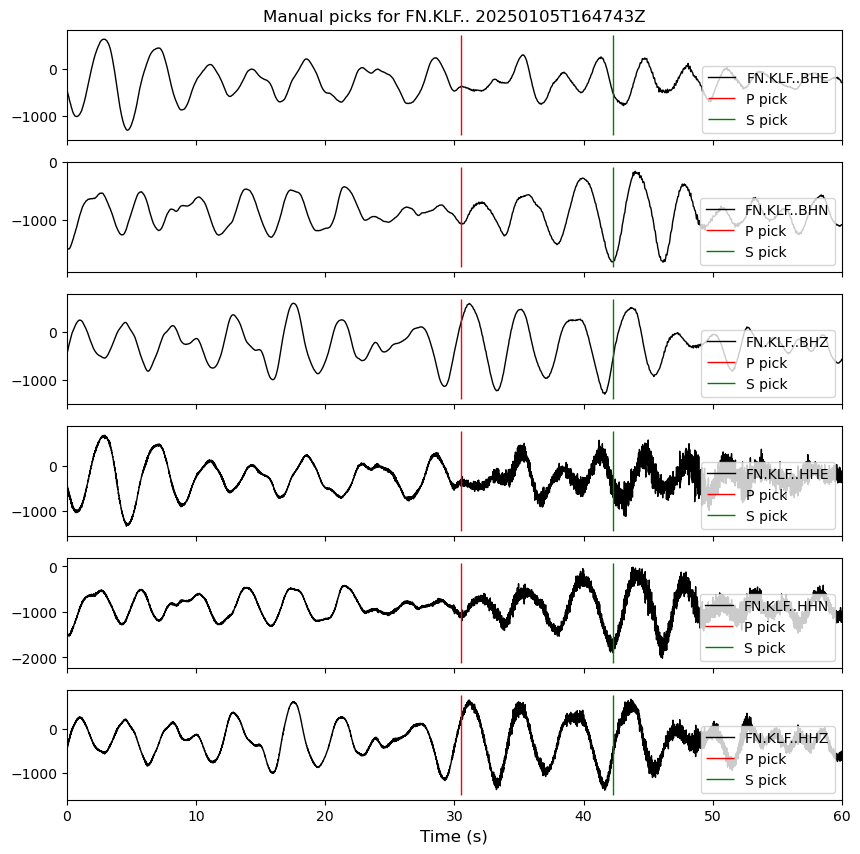

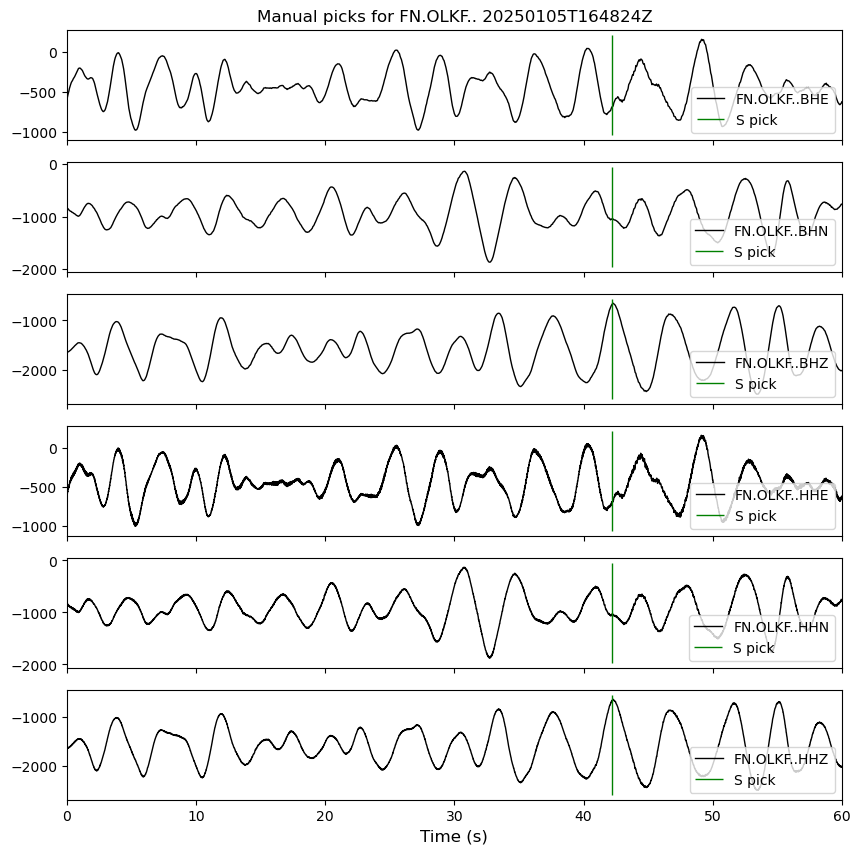

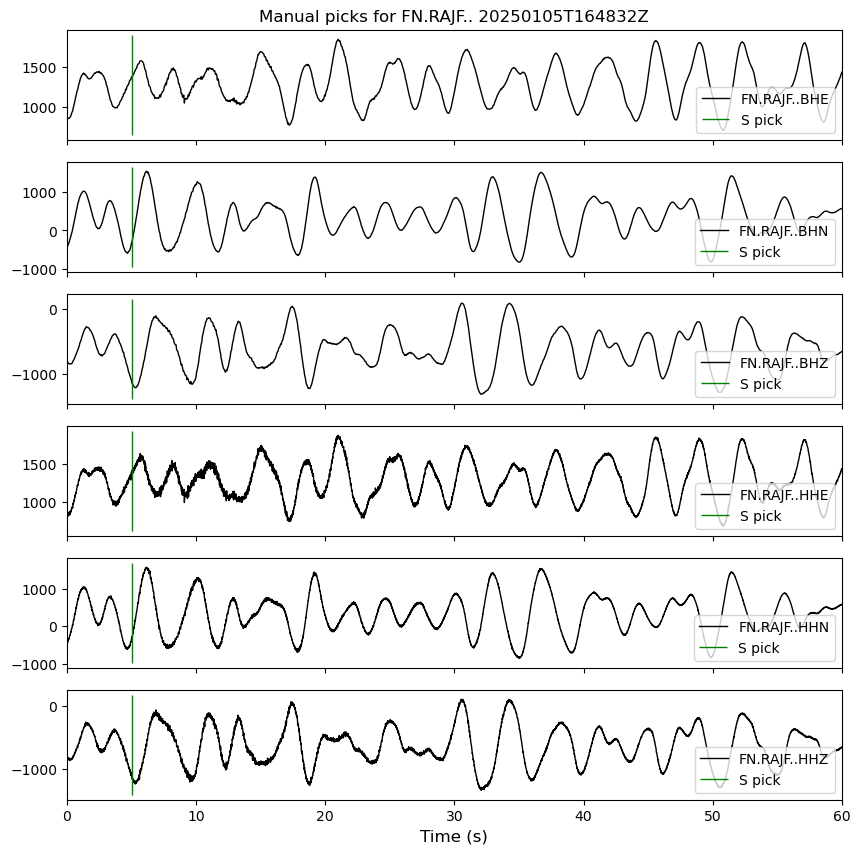

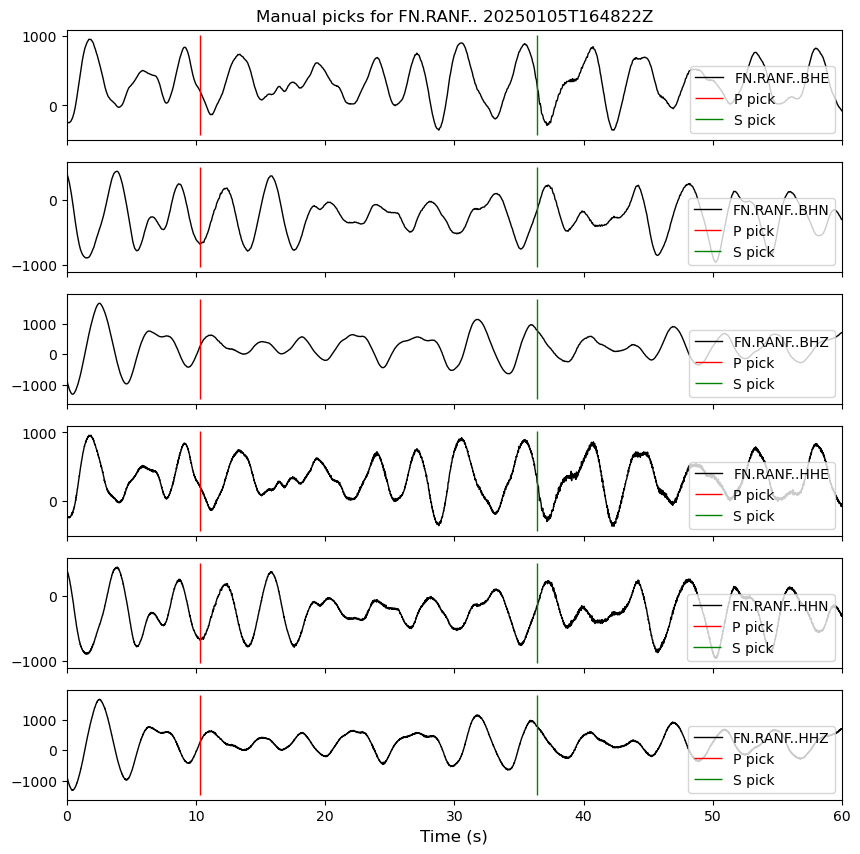

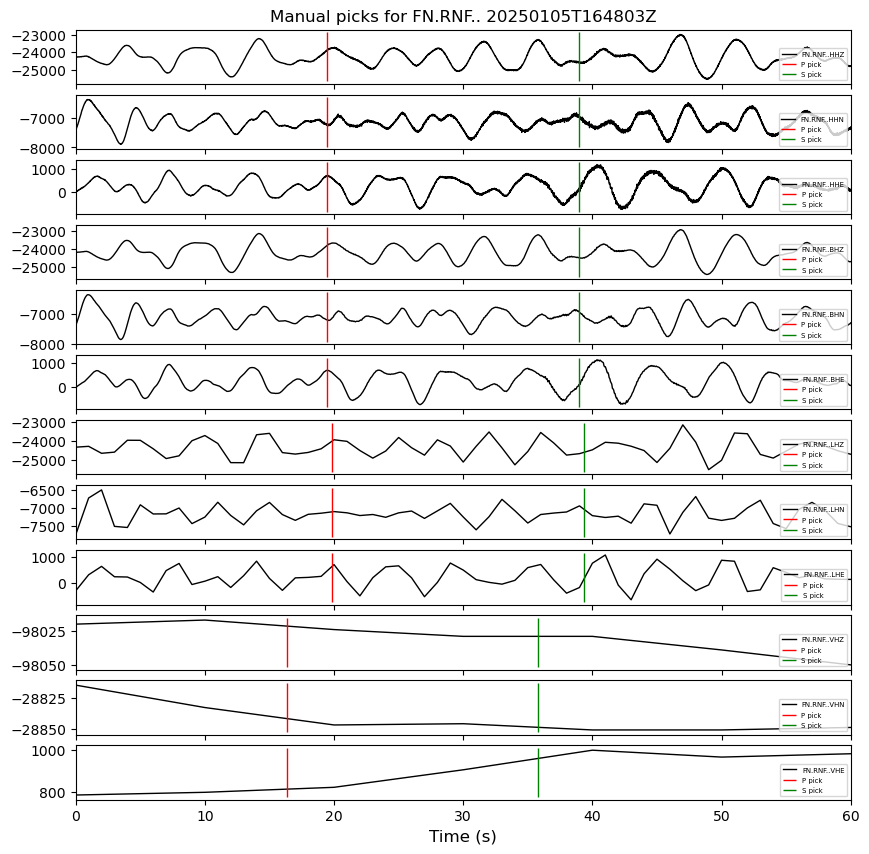

In [ ]:
max_rows = 5 # Maximum number of labels to read and plot

# Read the true P and S arrival times from labels.csv  
df_event_labels = pd.read_csv(utils.FILENAME_Y_EX, nrows=max_rows)

# Iterate through each label, loading waveforms and plotting the true P and S arrival times on them
for row in df_event_labels.itertuples():

    network_code, station_code, win_start, win_end = utils.parse_label_filename(row.file_name)
    p_time = utils.to_utc_or_none(row.p_arrival_time)
    s_time = utils.to_utc_or_none(row.s_arrival_time)
    
    # Load the corresponding waveform from the locally-stored dataset
    st = utils.load_stream(win_start, win_end, network_code, station_code, dir=utils.WAVEFORM_EX_DIR)

    if st:
        # If the waveform exists in the dataset, plot it with its true P and S arrival times
        utils.plot_traces(st,
                        ptime=p_time,
                        stime=s_time,
                        title=f"Manual picks for {network_code}.{station_code}.. {win_start}",
                        figname=Path(utils.VIS_DIR) / f"{network_code} {station_code} {win_start}.png", # If set, save plot as file
                        showf=True) # If set, show plot 

### Plot earthquake noise waveforms from local dataset

Load earthquake noise waveforms from the local dataset

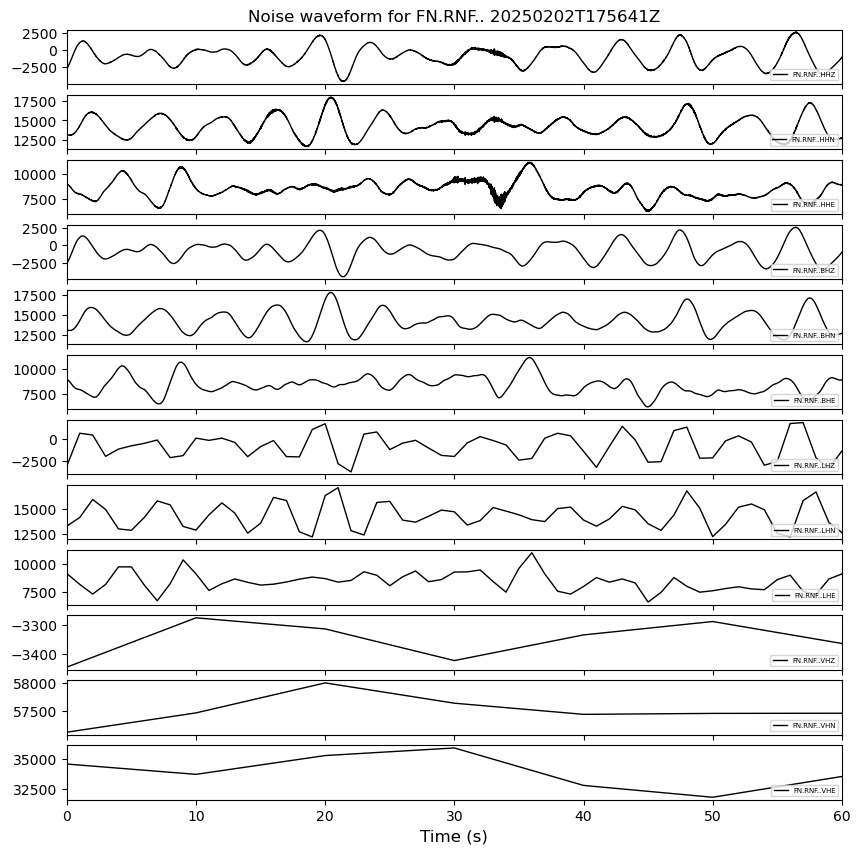

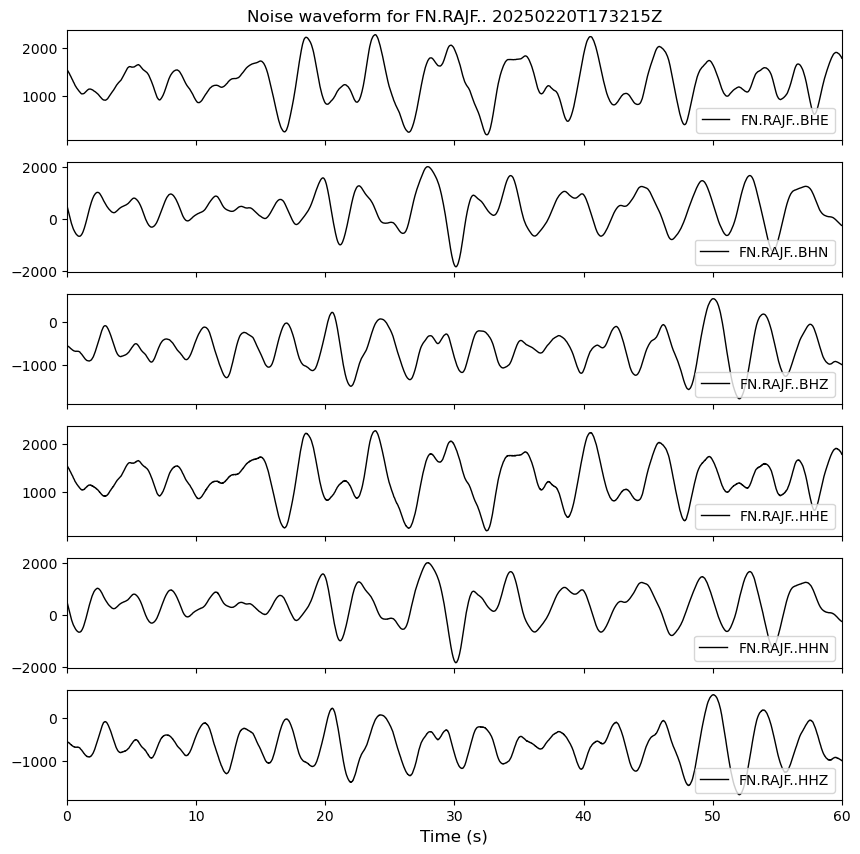

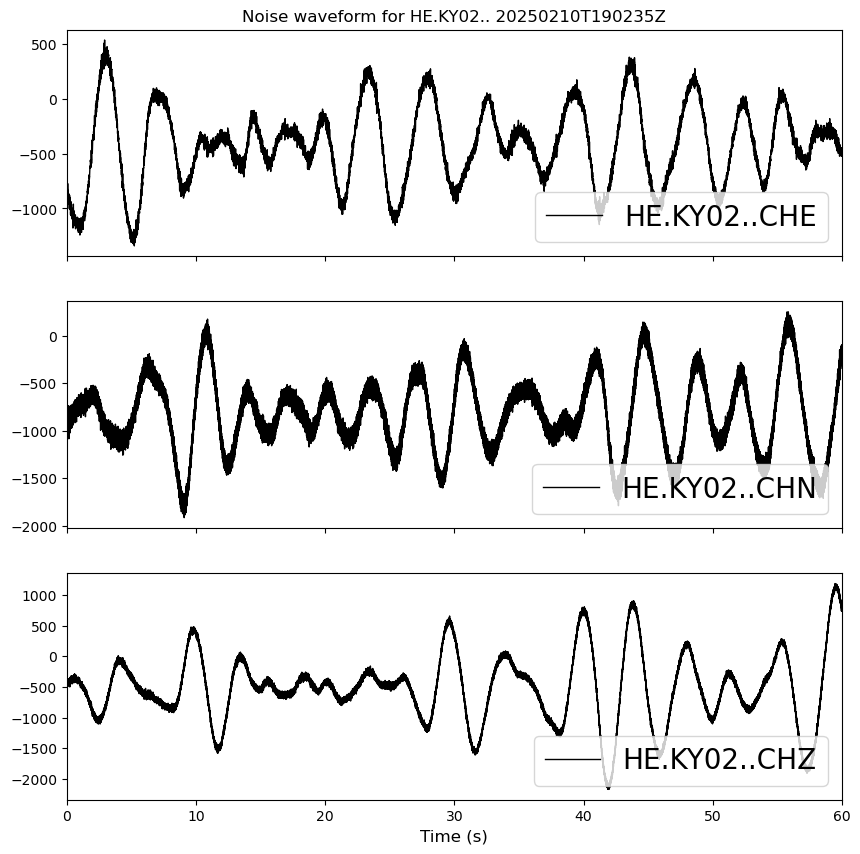

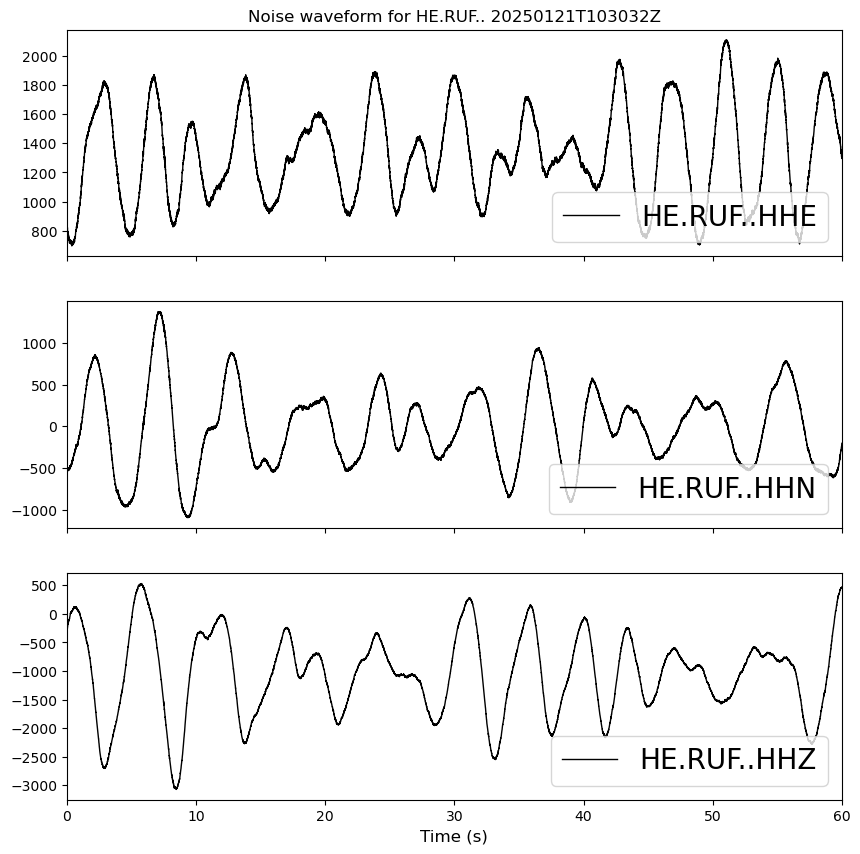

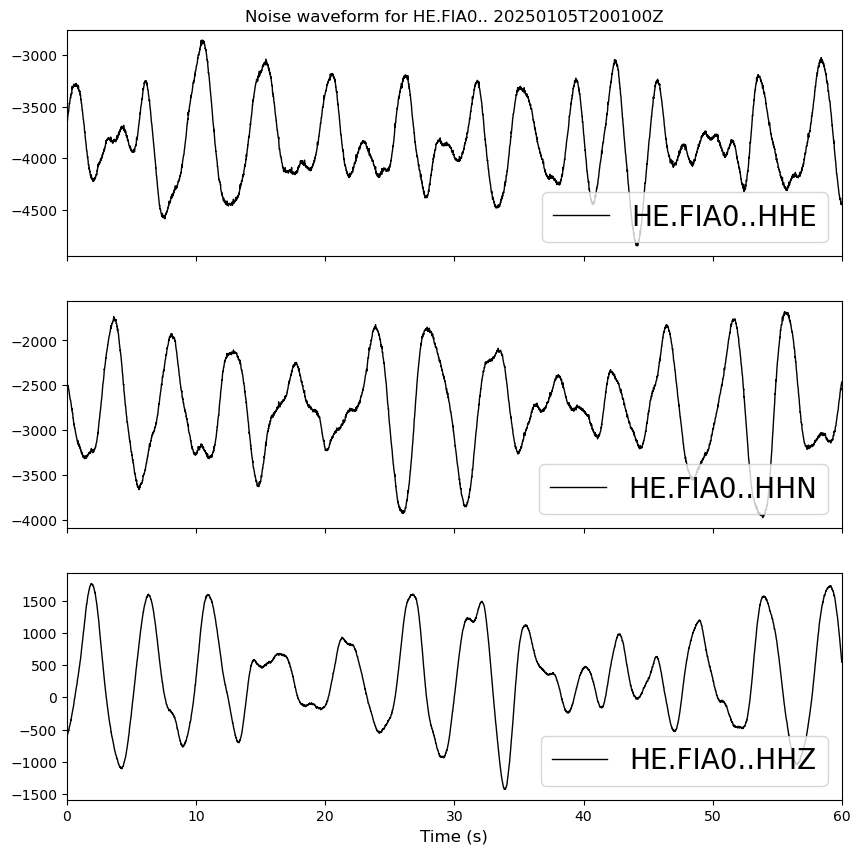

In [ ]:
max_rows = 5 # Maximum number of labels to read and plot

# Read the true P and S arrival times from labels.csv  
df_noise_labels = pd.read_csv(utils.FILENAME_Y_NOISE, nrows=max_rows)

# Iterate through each label, loading waveforms and plotting the true P and S arrival times on them
for row in df_noise_labels.itertuples():

    network_code, station_code, win_start, win_end = utils.parse_label_filename(row.file_name)
    
    # Load the corresponding waveform from the locally-stored dataset
    st = utils.load_stream(win_start, win_end, network_code, station_code, dir=utils.WAVEFORM_NOISE_DIR)
    p_time = utils.to_utc_or_none(row.p_arrival_time) # Placed here to demonstrate there are no picks
    s_time = utils.to_utc_or_none(row.s_arrival_time) # Placed here to demonstrate there are no picks
    
    if st:
        # If the waveform exists in the dataset, plot it with its true P and S arrival times
        utils.plot_traces(st,
                        ptime=p_time,
                        stime=s_time,
                        title=f"Noise waveform for {network_code}.{station_code}.. {win_start}",
                        figname=Path(utils.VIS_DIR) / f"{network_code} {station_code} {win_start}.png", # If set, save plot as file
                        showf=True) # If set, show plot 